In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq, curve_fit
import matplotlib.pyplot as plt

In [2]:
# Fast shooting method to solve the schrodinger equation dimensionless form for a free particle within [0, 1]
def solve_schrodinger(E_min, E_max, n_points, coarse):
    
    def ode(_, y, E):

        dydx = np.zeros(2)
        dydx[0] = y[1]
        dydx[1] = - E * y[0]
        return dydx
    
    def solve_for_E(E_value):

        y0 = np.array([0.0, 1.0])
        
        sol = solve_ivp(
            fun = lambda x, y: ode(x, y, E_value),
            t_span = [0, 1],
            y0 = y0,
            method = 'RK45',
            dense_output = True,
            vectorized = False
        )
        
        return sol.y[0, -1]
    
    def find_eigenvalues_in_range(E_min_local, E_max_local, n_points_local, coarse):
        eigenvalues = []
        
        # First pass: coarse scan
        coarse_points = n_points_local // coarse
        E_coarse = np.linspace(E_min_local, E_max_local, coarse_points)
        psi_coarse = np.zeros(coarse_points)
        
        for i, E in enumerate(E_coarse):
            psi_coarse[i] = solve_for_E(E)
        
        # Find coarse sign changes
        coarse_sign_changes = np.where(np.diff(np.sign(psi_coarse)))[0]
        
        # Second pass: refine only near sign changes
        for idx in coarse_sign_changes:
            if idx + 1 < len(E_coarse):

                # Try to use brentq directly
                try:
                    root = brentq(
                        solve_for_E,
                        E_coarse[idx],
                        E_coarse[idx + 1]
                    )

                    eigenvalues.append(root)
                    
                except Exception:

                    # If brentq fails, do a fine scan in this region
                    E_fine = np.linspace(E_coarse[idx], E_coarse[idx + 1], 20)
                    psi_fine = np.zeros_like(E_fine)
                    
                    for j, E_f in enumerate(E_fine):
                        psi_fine[j] = solve_for_E(E_f)
                    
                    fine_sign_changes = np.where(np.diff(np.sign(psi_fine)))[0]
                    for fine_idx in fine_sign_changes:

                        try:
                            root = brentq(
                                solve_for_E,
                                E_fine[fine_idx],
                                E_fine[fine_idx + 1]
                            )

                            eigenvalues.append(root)

                        except Exception:
                            continue
        
        # Sort eigenvalues
        eigenvalues.sort()

        return np.array(eigenvalues)
    
    # Main execution
    return find_eigenvalues_in_range(E_min, E_max, n_points, coarse)

In [3]:
energies = solve_schrodinger(E_min = 0,
                             E_max = 10_000,
                             n_points = 50_000,
                             coarse = 100
                             )

energies

array([   9.86558621,   39.45906306,   88.77729338,  157.82461682,
        246.59872309,  355.10009878,  483.32912442,  631.28379105,
        798.95865784,  986.36536654, 1193.49910208, 1420.36006494,
       1666.94705476, 1933.25959557, 2219.29082077, 2525.0493507 ,
       2850.54300241, 3195.76050263, 3560.70249427, 3945.37435204,
       4349.76401832, 4773.86775012, 5217.71925985, 5681.29080905,
       6164.58607028, 6667.60950279, 7190.34724391, 7732.80167061,
       8295.00606534, 8876.92869222, 9478.57041377])

In [4]:
# Define the fitting function: f(n; a) = (a * n)^2
fitting_func = lambda n, a: (a * n) ** 2

n_values = np.arange(1, len(energies) + 1)

# Perform the fit
popt, pcov = curve_fit(fitting_func, n_values, energies, p0 = [np.pi])

# Extract the best-fit parameter
a_opt = popt[0]
a_error = 2 * np.sqrt(pcov[0, 0])  # 2 * Standard error of the parameter

print(f"Optimal parameter a = {a_opt} ± {a_error}")
print(f"Theoretical value (pi) = {np.pi}")
print(f"Relative difference = {abs(a_opt - np.pi) / np.pi * 100:.3f} %")

Optimal parameter a = 3.1405915267175457 ± 4.700652413890355e-06
Theoretical value (pi) = 3.141592653589793
Relative difference = 0.032 %


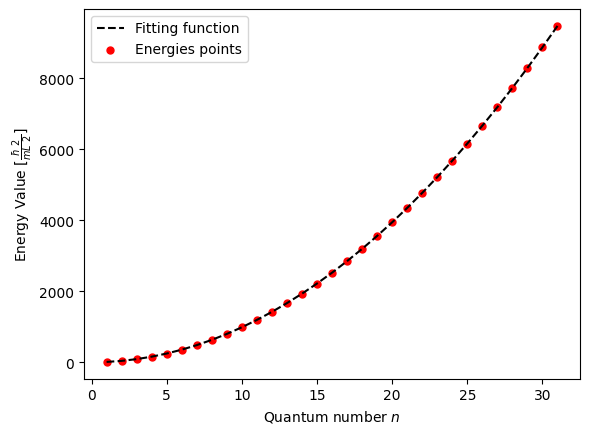

In [5]:
plt.plot(n_values, fitting_func(a_opt, n_values), '--', label = 'Fitting function', color = 'black')
plt.scatter(n_values, energies, label = 'Energies points', color = 'red', s = 25)
plt.xlabel(r"Quantum number $n$")
plt.ylabel(r"Energy Value [$\frac{\hbar ^ 2}{m L ^ 2}$]")
plt.legend()
plt.show()